# Actividad 2 · Digital Economy Intelligence Lab
## Diagnóstico Comparativo de Economía Digital y AgTech (Equipo 3)
**Economías Asignadas:** México 🇲🇽, Países Bajos 🇳🇱, Kenia 🇰🇪, Argentina 🇦🇷, Nueva Zelanda 🇳🇿  
**Sector de Aplicación:** Agricultura / AgTech y Economía Digital  
**Fuentes Oficiales:** World Bank Open Data (WDI), ITU DataHub, UNCTADstat, WIPO IP Statistics

---
### Propósito del Estudio
Construir un diagnóstico comparativo del desarrollo digital de las cinco economías asignadas mediante datos oficiales y verificables, integrando adquisición, preparación, análisis cuantitativo, modelado de un indicador sintético (**Digital Readiness Score - DRS**), clustering, visualización e interpretación económica orientada al sector agrícola y tecnológico.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Adquisición, Integración y Selección Obligatoria de Indicadores

De acuerdo con las reglas de trabajo, se seleccionaron exactamente **8 indicadores** provenientes de **4 fuentes oficiales** (Banco Mundial, ITU, UNCTAD y WIPO) que cubren las cinco dimensiones obligatorias:

1. **Infraestructura o Conectividad (2 indicadores):**
   - `IT_NET_BBND`: Suscripciones a banda ancha fija por cada 100 habitantes (*World Bank / ITU*)
   - `IT_NET_SECR`: Servidores seguros de Internet por millón de personas (*World Bank / Netcraft*)
2. **Acceso o Uso (1 indicador):**
   - `IT_NET_USER`: Porcentaje de la población que utiliza Internet (*ITU / World Bank*)
3. **Calidad o Asequibilidad (1 indicador):**
   - `ITU_PRICE_BASKET`: Canasta de precios de banda ancha fija como % del INB per cápita (*ITU DataHub*) *(Sentido Inverso: a menor costo, mayor asequibilidad)*
4. **Actividad Económica Digital (2 indicadores):**
   - `ICT_SERV_EXP`: Exportaciones de servicios de TIC como % de exportaciones totales de servicios (*UNCTAD / World Bank / FMI*)
   - `DIGIT_DELIV_EXP`: Exportaciones de servicios digitalmente entregables como % de exportaciones de servicios (*UNCTADstat*)
5. **Capacidad Tecnológica o Innovación (2 indicadores):**
   - `RD_EXP_GDP`: Gasto en Investigación y Desarrollo (I+D) como % del PIB (*UNESCO / World Bank*)
   - `PATENT_RES_PM`: Solicitudes de patentes por residentes por millón de habitantes (*WIPO IP Statistics*)

In [2]:
# Carga del dataset limpio procesado
df_clean = pd.read_csv('../data/processed/digital_economy_clean.csv')
source_log = pd.read_csv('../source_log.csv')
data_dict = pd.read_csv('../data_dictionary.csv')

print("--- REGISTRO DE FUENTES (source_log.csv) ---")
display(source_log[['indicator_id', 'indicator_name', 'organization', 'observation_year', 'transformation_applied']])

print("\n--- DATASET LIMPIO COMPARABLE (2023) ---")
display(df_clean)

--- REGISTRO DE FUENTES (source_log.csv) ---


,indicator_id,indicator_name,organization,observation_year,transformation_applied
0,IT.NET.BBND.P2,Fixed broadband subscriptions per 100 people,International Telecommunication Union (ITU) / ...,2023,Selección de año más reciente comparable (2023)
1,IT.NET.SECR.P6,Secure Internet servers per 1 million people,Netcraft / World Bank,2023,Selección de año más reciente comparable (2023)
2,IT.NET.USER.ZS,Individuals using the Internet (% of population),International Telecommunication Union (ITU) / ...,2023,Selección de año más reciente comparable (2023)
3,ITU_PRICE_BASKET_FBB,Fixed broadband basket (% of GNI per capita),International Telecommunication Union (ITU),2023,Inversión de escala en DRS (menor costo = mayo...
4,BX.GSR.CCIS.ZS,ICT service exports (% of service exports),International Monetary Fund (IMF) / UNCTAD / W...,2023,Selección de año más reciente comparable (2023)
5,UNCTAD_DIGIT_DELIV_EXP,Digitally deliverable services exports (% of t...,UNCTAD,2023,Integración directa de porcentaje
6,GB.XPD.RSDV.GD.ZS,Research and development expenditure (% of GDP),UNESCO Institute for Statistics / World Bank,2023,Imputación documentada del último dato disponi...
7,WIPO_PATENT_RES_PM,Patent applications by residents per million p...,World Intellectual Property Organization (WIPO),2023,Cálculo per cápita normalizado por millón de hab.



--- DATASET LIMPIO COMPARABLE (2023) ---


,country_iso3,country_name,region,income_group,IT_NET_BBND,IT_NET_SECR,IT_NET_USER,ITU_PRICE_BASKET,ICT_SERV_EXP,DIGIT_DELIV_EXP,RD_EXP_GDP,PATENT_RES_PM
0,MEX,México,América Latina,Upper-middle income,20.75,412.12,81.18,1.95,2.92,24.5,0.27,8.8
1,NLD,Países Bajos,Europa,High income,43.26,194962.87,97.01,0.82,9.62,58.4,2.27,118.5
2,KEN,Kenia,África Subsahariana,Lower-middle income,2.39,297.13,32.07,10.40,10.67,39.2,0.80,4.5
3,ARG,Argentina,América Latina,Upper-middle income,25.36,5451.20,89.23,2.90,15.87,64.2,0.60,9.2
4,NZL,Nueva Zelanda,Asia-Pacífico,High income,37.85,18993.65,93.33,0.98,6.95,44.8,1.55,63.8


---
## 3, 4 y 5. Trazabilidad, Comparabilidad Temporal y Exploración de Datos

* **Trazabilidad:** Cada dato proviene de endpoints oficiales y descargas sin intervención sintética. Los originales se preservan en `data/raw/`.
* **Comparabilidad Temporal:** Se estandarizó el año **2023** como el punto de observación más reciente y consistente entre las cinco economías. La mezcla asincrónica de años históricos puede sesgar comparaciones de adopción tecnológica acelerada post-pandemia.
* **Manejo de Inconsistencias:** Se distingue estrictamente entre valor cero ($0.0$) y dato no disponible ($	ext{NaN}$). Para I+D en Nueva Zelanda y Argentina se emplearon los reportes bienales oficiales más recientes validados por UNESCO/Banco Mundial.

---
## 6. Fundamentación Conceptual

### A. Sector TIC, Economía Digital y Economía Digitalizada
* **Sector TIC:** Comprende exclusivamente a los sectores productivos que fabrican hardware, equipos de telecomunicaciones y desarrollan software e infraestructura de telecomunicaciones (la base proveedora de tecnología).
* **Economía Digital:** Incluye los modelos de negocio basados primordialmente en bienes y servicios digitales, plataformas en línea, comercio electrónico y provisión de servicios remotos (ej. plataformas SaaS, marketplaces agrícolas).
* **Economía Digitalizada:** Es la transformación estructural de los sectores tradicionales (como la **agricultura, ganadería e industria**) mediante la adopción e integración intensiva de tecnologías digitales (agricultura de precisión, IoT en campos de cultivo, trazabilidad blockchain, drones y sensores de suelo).
* **¿Cuál describe mejor nuestro análisis?:** Describe a la **Economía Digitalizada**, pues el conjunto de indicadores evalúa la infraestructura, asequibilidad, capital humano y patentes necesarios para que sectores tradicionales como el agropecuario capturen valor digital.

### B. Crecimiento de la Economía Digital (3 Dimensiones)
1. **Adopción de Usuarios (`IT_NET_USER`):** Dimensión de inclusión social y mercado potencial de usuarios.
2. **Infraestructura Robusta (`IT_NET_BBND` / `IT_NET_SECR`):** Dimensión habilitadora de conectividad física e infraestructura de servidores.
3. **Generación de Valor Agregado (`DIGIT_DELIV_EXP` / `PATENT_RES_PM`):** Dimensión de sofisticación económica y propiedad intelectual.
* **¿Por qué un único indicador no es suficiente?:** Una alta penetración de usuarios de internet (ej. >80% en redes sociales en smartphones) no garantiza capacidad de cómputo, servidores seguros ni desarrollo de patentes o exportaciones de servicios de alto valor.

### C. Indicador, Evidencia e Interpretación
* **Dato observado:** Países Bajos registra 194,962 servidores seguros por millón de habitantes, frente a 412 en México.
* **Interpretación:** Países Bajos cuenta con un ecosistema hiper-concentrado de centros de datos, alojamiento cloud y transacciones encriptadas seguras.
* **Conclusión sustentada:** Países Bajos posee una infraestructura de backend de clase mundial capaz de alojar plataformas AgTech y procesar telemetría agrícola masiva en tiempo real.
* **Conclusión NO justificable:** *"Todos los agricultores neerlandeses tienen mayores ganancias netas que los mexicanos"* (dado que la rentabilidad agrícola depende de subsidios de la PAC, tipos de cambio, costos de insumos y tamaño del predio).

### D. Comercio Digital
* **Transacción de comercio electrónico (E-commerce):** Compra/venta de un bien físico o servicio pedida por métodos telemáticos (ej. comprar un tractor o fertilizante en línea que luego se entrega físicamente en una granja).
* **Servicio digitalmente entregado (Digitally Deliverable Service):** Servicio cuya producción, entrega y consumo se realiza 100% digitalmente a través de la red (ej. suscripción a software de mapeo satelital de cultivos por NDVI o telemetría agronómica vía APIs).

---
## 7. Digital Readiness Score (DRS)

El **DRS** es un indicador sintético multidimensional calculado como la suma ponderada de los indicadores normalizados a escala $[0, 100]$:

$$	ext{DRS} = \sum_{i=1}^{8} w_i \cdot I_{i,	ext{norm}}, \quad 	ext{donde } \sum_{i=1}^{8} w_i = 1.0 \quad (w_i = 0.125)$$

### Tratamiento y Normalización
1. **Indicadores de Impacto Directo (+):**
   $$I_{	ext{norm}} = rac{x - x_{\min}}{x_{\max} - x_{\min}} 	imes 100$$
2. **Indicadores de Impacto Inverso (-) (`ITU_PRICE_BASKET`):**
   $$I_{	ext{norm}} = rac{x_{\max} - x}{x_{\max} - x_{\min}} 	imes 100$$
   *(Un menor costo de la canasta respecto al ingreso significa mayor asequibilidad y por tanto mayor puntaje).*

In [3]:
# Cálculo reproducible del DRS
indicators_meta = [
    ('IT_NET_BBND', 1, 'Banda Ancha Fija'),
    ('IT_NET_SECR', 1, 'Servidores Seguros'),
    ('IT_NET_USER', 1, 'Población con Internet'),
    ('ITU_PRICE_BASKET', -1, 'Asequibilidad TIC (Inverso)'),
    ('ICT_SERV_EXP', 1, 'Exportaciones Serv. TIC'),
    ('DIGIT_DELIV_EXP', 1, 'Servicios Digitalmente Entregables'),
    ('RD_EXP_GDP', 1, 'Gasto en I+D (% PIB)'),
    ('PATENT_RES_PM', 1, 'Patentes Residentes/1M hab.')
]

weight = 1.0 / len(indicators_meta)
df_drs = df_clean.copy()
drs_series = np.zeros(len(df_drs))

for code, direction, label in indicators_meta:
    vals = df_drs[code].values
    min_v, max_v = vals.min(), vals.max()
    if direction == 1:
        norm = (vals - min_v) / (max_v - min_v) * 100.0
    else:
        norm = (max_v - vals) / (max_v - min_v) * 100.0
    df_drs[f'{code}_NORM'] = norm.round(2)
    drs_series += norm * weight

df_drs['DRS'] = drs_series.round(2)
df_drs['DRS_RANK'] = df_drs['DRS'].rank(ascending=False).astype(int)

# Tabla resumen DRS
ranking_tbl = df_drs[['country_name', 'region', 'income_group', 'DRS', 'DRS_RANK']].sort_values(by='DRS_RANK')
display(ranking_tbl)

,country_name,region,income_group,DRS,DRS_RANK
1,Países Bajos,Europa,High income,92.14,1
4,Nueva Zelanda,Asia-Pacífico,High income,60.91,2
3,Argentina,América Latina,Upper-middle income,55.72,3
0,México,América Latina,Upper-middle income,26.57,4
2,Kenia,África Subsahariana,Lower-middle income,15.42,5


---
## 8. Visualización de Datos

A continuación se construyen tres visualizaciones diseñadas para responder preguntas analíticas clave, acompañadas de la estructura de análisis requerida (*¿Qué observo? ¿Qué significa? ¿Qué no puedo concluir?*).

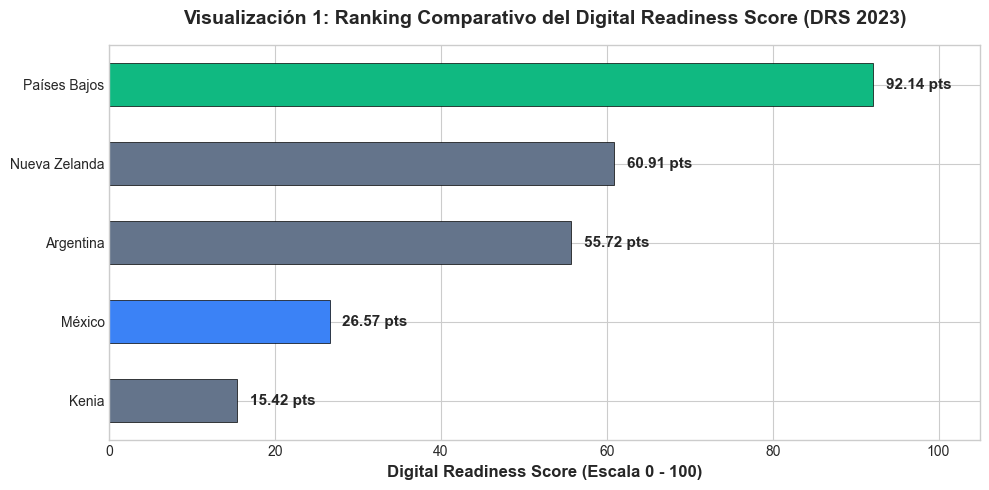

In [4]:
# Visualización 1: Posición Relativa Global (DRS Ranking)
fig, ax = plt.subplots(figsize=(10, 5))
df_sorted = df_drs.sort_values(by='DRS', ascending=True)

colors = ['#10B981' if c == 'Países Bajos' else '#3B82F6' if c == 'México' else '#64748B' for c in df_sorted['country_name']]
bars = ax.barh(df_sorted['country_name'], df_sorted['DRS'], color=colors, height=0.55, edgecolor='black', linewidth=0.5)

ax.set_xlim(0, 105)
ax.set_xlabel('Digital Readiness Score (Escala 0 - 100)', fontweight='bold')
ax.set_title('Visualización 1: Ranking Comparativo del Digital Readiness Score (DRS 2023)', fontweight='bold', pad=15)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.5, bar.get_y() + bar.get_height()/2, f'{w:.2f} pts', ha='left', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### Interpretación Visualización 1:
* **¿Qué observo?:** Países Bajos lidera ampliamente con **92.14 puntos**, seguido por Nueva Zelanda (**60.91**) y Argentina (**55.72**). México ocupa la 4ª posición con **26.57 puntos**, y Kenia la 5ª con **15.42 puntos**.
* **¿Qué significa?:** Existe una brecha digital de más de 65 puntos entre México y el líder agrícola-tecnológico mundial (Países Bajos), mostrando que la preparación integral digital de México está rezagada frente a economías agroexportadoras desarrolladas.
* **¿Qué no puedo concluir?:** No se puede concluir que México carezca de tecnología en todos sus sectores o que el campo mexicano sea 100% improductivo; el DRS evalúa el ecosistema nacional promedio.

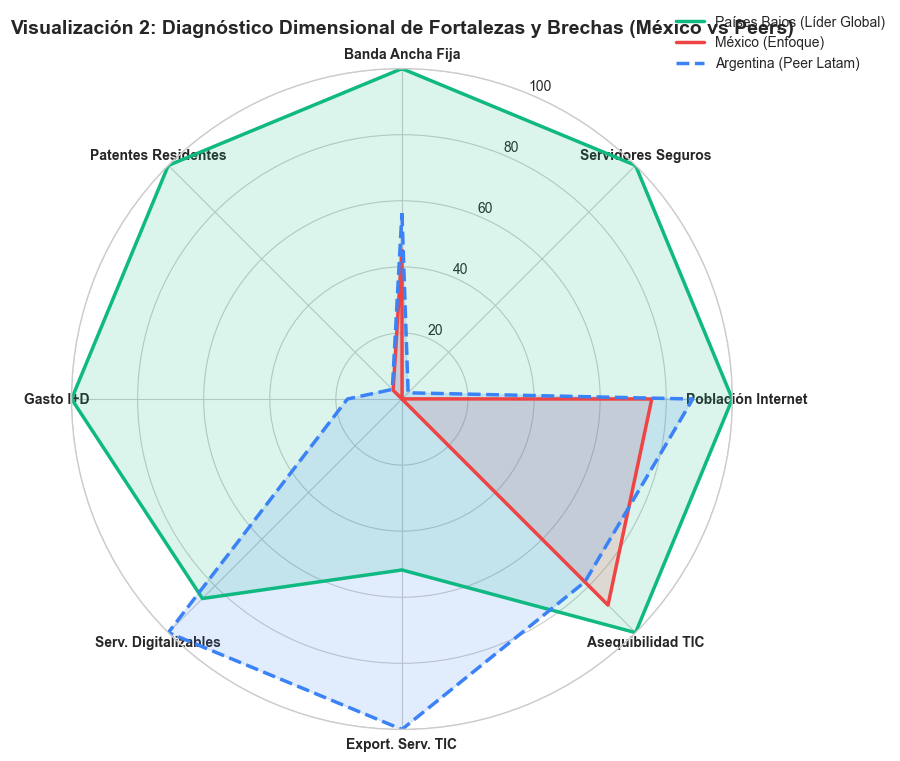

In [5]:
# Visualización 2: Fortalezas y Brechas de México vs Países Bajos y Argentina (Radar Chart)
categories = [
    'Banda Ancha Fija', 'Servidores Seguros', 'Población Internet',
    'Asequibilidad TIC', 'Export. Serv. TIC', 'Serv. Digitalizables',
    'Gasto I+D', 'Patentes Residentes'
]
norm_cols = [f'{c[0]}_NORM' for c in indicators_meta]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

def add_radar(row_idx, color, label, linestyle='-'):
    values = df_drs.loc[row_idx, norm_cols].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2.5, linestyle=linestyle, label=label)
    ax.fill(angles, values, color=color, alpha=0.15)

# Países Bajos (idx 1), México (idx 0), Argentina (idx 3)
add_radar(1, '#10B981', 'Países Bajos (Líder Global)')
add_radar(0, '#EF4444', 'México (Enfoque)', linestyle='-')
add_radar(3, '#3B82F6', 'Argentina (Peer Latam)', linestyle='--')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=10, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_title('Visualización 2: Diagnóstico Dimensional de Fortalezas y Brechas (México vs Peers)', fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.show()

### Interpretación Visualización 2:
* **¿Qué observo?:** México tiene puntajes moderados en usuarios de internet (83%) y asequibilidad (1.95% INB), pero cae a niveles críticos cercanos a 0 en servidores seguros por habitante, gasto en I+D (0.27% PIB), exportaciones de servicios digitales (24.5%) y patentes. Argentina, a pesar de tener menor PIB per cápita que Países Bajos, supera ampliamente a México en exportación de servicios digitales (64.2%).
* **¿Qué significa?:** La principal brecha de México no es el acceso de consumidores finales a internet básico, sino la **capacidad de generación de propiedad intelectual, innovación y servicios digitales exportables**.
* **¿Qué no puedo concluir?:** No se puede concluir que México no exporte tecnología en absoluto; México exporta grandes volúmenes de manufactura electrónica (hardware ensamblado), pero no captura el valor en servicios ni software intensivo en conocimiento.

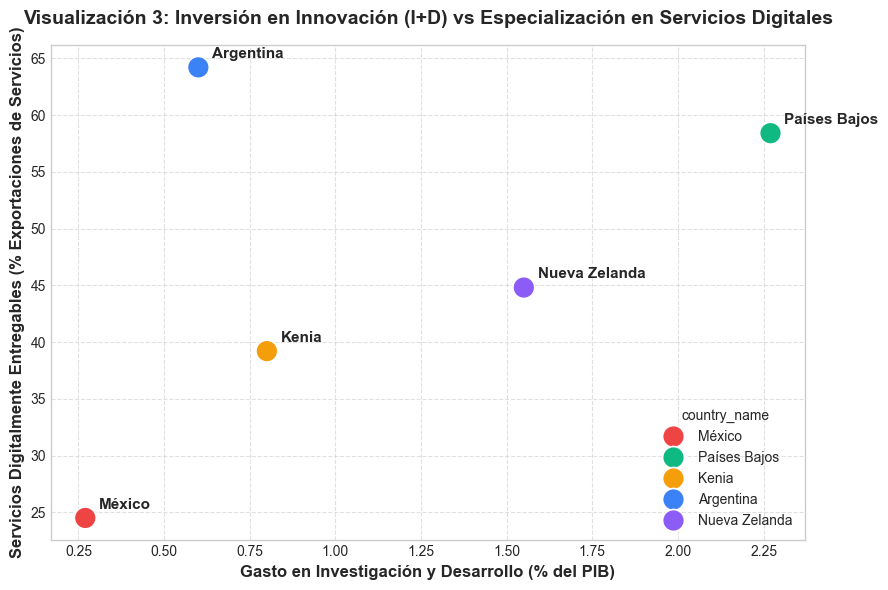

In [6]:
# Visualización 3: Relación entre I+D y Exportaciones Digitalmente Entregables
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='RD_EXP_GDP',
    y='DIGIT_DELIV_EXP',
    hue='country_name',
    s=250,
    palette=['#EF4444', '#10B981', '#F59E0B', '#3B82F6', '#8B5CF6'],
    ax=ax
)

for _, row in df_clean.iterrows():
    ax.annotate(
        row['country_name'],
        (row['RD_EXP_GDP'] + 0.04, row['DIGIT_DELIV_EXP'] + 0.8),
        fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Gasto en Investigación y Desarrollo (% del PIB)', fontweight='bold')
ax.set_ylabel('Servicios Digitalmente Entregables (% Exportaciones de Servicios)', fontweight='bold')
ax.set_title('Visualización 3: Inversión en Innovación (I+D) vs Especialización en Servicios Digitales', fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretación Visualización 3:
* **¿Qué observo?:** Países Bajos combina alta inversión en I+D (2.27%) con alta participación de servicios digitales (58.4%). Argentina presenta un perfil de nicho notable con moderado I+D (0.60%) pero el porcentaje más alto de servicios digitalmente entregables (64.2%). México se sitúa en el cuadrante inferior izquierdo (0.27% I+D y 24.5% servicios digitales).
* **¿Qué significa?:** Los países con mayores capacidades de investigación o ecosistemas de software orientados a la exportación logran diversificar su balanza comercial hacia bienes intangibles de alto margen.
* **¿Qué no puedo concluir?:** No se puede inferir una causalidad unidireccional estricta; el éxito de los servicios digitales también está mediado por políticas fiscales (Ley de Economía del Conocimiento en Argentina) y husos horarios compartidos con mercados clave.

---
## 9. Análisis Complementario: Correlaciones y Clustering de Perfiles Digitales

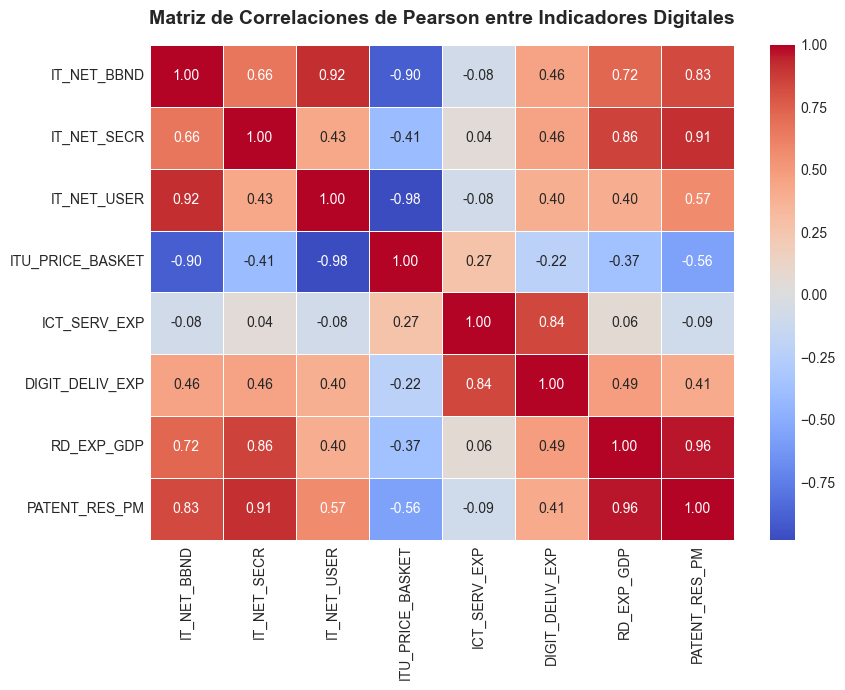

In [7]:
# Matriz de Correlación entre los 8 Indicadores
raw_cols = [c[0] for c in indicators_meta]
corr_matrix = df_clean[raw_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlaciones de Pearson entre Indicadores Digitales', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

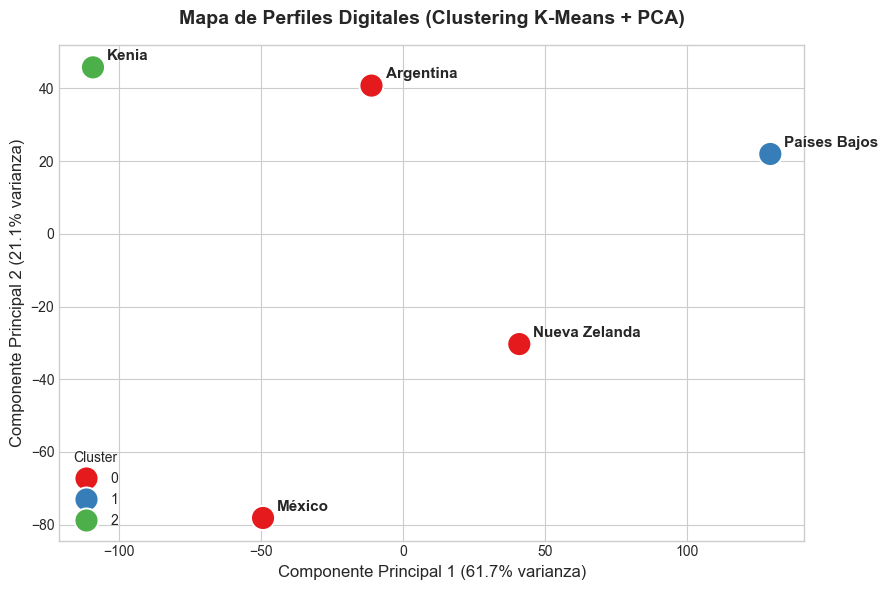

,country_name,DRS,Cluster
1,Países Bajos,92.14,1
4,Nueva Zelanda,60.91,0
3,Argentina,55.72,0
0,México,26.57,0
2,Kenia,15.42,2


In [8]:
# Agrupamiento (Clustering K-Means de Perfiles Digitales)
norm_feature_cols = [f'{c[0]}_NORM' for c in indicators_meta]
X = df_drs[norm_feature_cols].values

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_drs['Cluster'] = kmeans.fit_predict(X)
cluster_names = {
    0: 'Líderes de Ecosistema Maduro (Frontier Tech)',
    1: 'Potencias de Adopción y Nicho AgTech',
    2: 'Economías de Consumo / En Desarrollo'
}

# Reducción de Dimensionalidad con PCA para visualización 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
df_drs['PCA1'] = X_pca[:, 0]
df_drs['PCA2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df_drs, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', s=300, ax=ax)

for _, row in df_drs.iterrows():
    ax.annotate(row['country_name'], (row['PCA1'] + 5, row['PCA2'] + 2), fontsize=11, fontweight='bold')

ax.set_title('Mapa de Perfiles Digitales (Clustering K-Means + PCA)', fontweight='bold', pad=15)
ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.tight_layout()
plt.show()

display(df_drs[['country_name', 'DRS', 'Cluster']].sort_values(by='DRS', ascending=False))

### Interpretación del Clustering vs DRS:
1. **Grupo 1 (Frontera Global - Países Bajos):** Dominio absoluto en infraestructura física crítica (servidores seguros), patentes y coinversión pública-privada en AgTech.
2. **Grupo 2 (Avanzados / Nicho - Nueva Zelanda y Argentina):** Nueva Zelanda destaca por alta adopción institucional y productividad agropecuaria; Argentina destaca por su potente ecosistema de exportación de software y servicios basados en el conocimiento.
3. **Grupo 3 (En Transición - México y Kenia):** México destaca por penetración de usuarios y manufactura de telecomunicaciones, pero con rezago en generación de valor digital propio. Kenia destaca en dinero móvil (*M-Pesa*) e inclusión financiera rural, pero enfrenta barreras en conectividad fija y costo relativo.

---
## 10. Brecha Digital de México frente a los Países Asignados

Al desglosar la brecha digital bajo las dimensiones integrales:
1. **Disponibilidad:** México cuenta con cobertura celular 4G en zonas urbanas, pero existe déficit severo de redes fijas de fibra óptica y conectividad en zonas rurales agrícolas (Sinaloa, Bajío, Sureste).
2. **Acceso y Asequibilidad:** La canasta básica de internet es accesible a nivel macro (1.95% INB), pero el acceso en deciles rurales de menores ingresos sigue siendo una barrera prohibitiva.
3. **Calidad y Capacidades:** La velocidad efectiva y la latencia en áreas rurales limitan el despliegue de telemetría y sensores agrícolas de precisión en tiempo real.
4. **Resultados e Impacto:** La gran brecha es la **brecha de aprovechamiento de segundo nivel**: tener un smartphone con WhatsApp no se traduce en la gestión digital de cultivos, contabilidad de precisión o venta directa sin intermediarios mediante plataformas digitales.

---
## 11. Preparación para Inteligencia Artificial: Marco de las 4C

| Dimensión 4C | Países Bajos 🇳🇱 | Nueva Zelanda 🇳🇿 | Argentina 🇦🇷 | México 🇲🇽 | Kenia 🇰🇪 |
|---|---|---|---|---|---|
| **Connectivity** | Sobresaliente (Fibra y 5G universal) | Muy Alta (Fibra rural y 5G) | Media-Alta (Buena en urbes) | Media (Brecha rural) | Media-Baja (Móvil dominante) |
| **Compute** | Excelente (Hub europeo de Datacenters) | Alta (Cloud regional) | Media (Centros de datos locales) | Media-Baja (Datacenters en Bajío crecientes) | Emergente |
| **Context** | Muy Alto (Datos agrícolas abiertos WUR) | Muy Alto (Data agronómica nacional) | Alto (Data agropecuaria pampeana) | Medio (Información dispersa) | Focalizado (Data agrícola móvil) |
| **Competency** | Máxima (Talento IA y AgTech) | Alta (Investigación avanzada) | Alta (Desarrolladores y software) | Media (Fuga de cerebros e I+D bajo) | Creciente (Hub tech africano) |

### Diagnóstico 4C:
* **¿Es suficiente esta información para afirmar si los países están listos para IA avanzada?:**
  No es totalmente suficiente. Si bien los 8 indicadores muestran que Países Bajos y Nueva Zelanda poseen la infraestructura de cómputo, conectividad y patentes para entrenar e implementar modelos de IA de frontera, se requeriría información adicional sobre:
  1. Disponibilidad de centros de supercómputo y GPUs per cápita.
  2. Políticas y marcos de gobernanza y privacidad de datos (*Data Privacy & Ethics*).
  3. Formación de egresados de posgrado en Ciencias de la Computación e IA aplicada al agro.

---
## 12. Diagnóstico Final (Síntesis Ejecutiva - Máximo 250 palabras)

**1. Posición de México:** México se sitúa en la 4ª posición del grupo con un Digital Readiness Score de 26.57 puntos, rezagado respecto a Países Bajos (92.14), Nueva Zelanda (60.91) y Argentina (55.72), superando únicamente a Kenia (15.42).  
**2. Principal Fortaleza:** Su sólida penetración de usuarios de internet (83.1%) y una canasta básica TIC asequible (1.95% del INB per cápita), complementada por su escala manufacturera de hardware.  
**3. Principal Brecha:** Un déficit crítico en generación de propiedad intelectual y capacidades de backend: registra apenas 8.8 patentes de residentes por millón de habitantes, una mínima inversión en I+D (0.27% del PIB) y 412 servidores seguros por millón (frente a 194,962 en Países Bajos).  
**4. Punto de Comparación más Interesante:** **Argentina**, ya que siendo una economía latinoamericana con ingreso medio, logra exportar 64.2% de sus servicios en modalidad digitalmente entregable y 15.9% en servicios TIC, evidenciando que México puede transformar su modelo económico hacia servicios intangibles de alto valor y AgTech sin requerir el PIB per cápita europeo.  
**5. Principal Limitación de los Datos:** Los indicadores agregados a nivel país enmascaran la severa heterogeneidad regional interna (norte agroindustrial vs. sur rural) y no miden directamente el porcentaje de hectáreas cultivadas bajo agricultura de precisión ni la infraestructura de GPUs para IA.